# Spam Detection using Machine Learning

## Objective

Build a machine learning model to classify SMS messages as **spam** or **ham**.

## Algorithms Used

- Support Vector Machine (SVM)
- Multinomial Naive Bayes

## Techniques Used

- Text Preprocessing
- CountVectorizer
- TF-IDF Vectorizer
- Train-Test Split
- Cross Validation
- GridSearchCV
- RandomizedSearchCV

## Dataset

- SMS Spam Collection Dataset
- Total messages: 5,574

## Workflow

1. Load the dataset
2. Explore and preprocess the data
3. Convert text into numerical features
4. Train machine learning models
5. Evaluate the models
6. Tune hyperparameters
7. Compare the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../datasets/SMSSpamCollection.csv", sep="\t", header=None, names=["label", "message"])

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.shape

(5572, 2)

In [7]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df.drop_duplicates(inplace=True)

df.shape

(5169, 2)

In [11]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

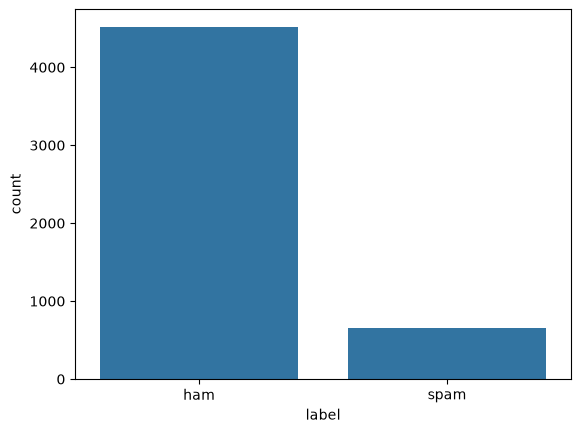

In [12]:
sns.countplot(data=df, x="label")
plt.show()

In [13]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [14]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(df['message'])
print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(5169, 8713)


In [18]:
print(cv.get_feature_names_out()[:20])

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '02073162414'
 '02085076972' '021' '03' '04' '0430' '05' '050703']


In [19]:
print(cv.get_feature_names_out()[:50])

print(X[0].toarray())

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '02073162414'
 '02085076972' '021' '03' '04' '0430' '05' '050703' '0578' '06' '07'
 '07008009200' '07046744435' '07090201529' '07090298926' '07099833605'
 '07123456789' '0721072' '07732584351' '07734396839' '07742676969'
 '07753741225' '0776xxxxxxx' '07781482378' '07786200117' '077xxx' '078'
 '07801543489' '07808' '07808247860' '07808726822' '07815296484'
 '07821230901' '078498' '07880867867' '0789xxxxxxx' '07946746291'
 '0796xxxxxx']
[[0 0 0 ... 0 0 0]]


In [20]:
print(df["message"][0])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [21]:
feature_names = cv.get_feature_names_out()

print(feature_names[:20])

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '02073162414'
 '02085076972' '021' '03' '04' '0430' '05' '050703']


In [22]:
print(X[0].sum())

18


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["message"])



In [24]:
X = tfidf.fit_transform(df["message"])

y = df["label"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

label
0    0.87367
1    0.12633
Name: proportion, dtype: float64
label
0    0.873761
1    0.126239
Name: proportion, dtype: float64
label
0    0.873308
1    0.126692
Name: proportion, dtype: float64


In [29]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9526112185686654
Precision: 1.0
Recall   : 0.6259541984732825
F1 Score : 0.7699530516431925


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[903   0]
 [ 49  82]]


In [32]:
from sklearn.svm import SVC
svm = SVC()
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9729206963249516
Precision: 0.9724770642201835
Recall   : 0.8091603053435115
F1 Score : 0.8833333333333333


In [36]:
from sklearn.model_selection import cross_val_score

nb_scores = cross_val_score(
    MultinomialNB(),
    X,
    y,
    cv=5,
    scoring="f1"
)

print(nb_scores)
print(nb_scores.mean())

[0.83928571 0.72815534 0.79816514 0.78139535 0.76190476]
0.7817812604896379


In [37]:
svm_scores = cross_val_score(
    SVC(),
    X,
    y,
    cv=5,
    scoring="f1"
)

print(svm_scores)
print(svm_scores.mean())

[0.9        0.88034188 0.88607595 0.87553648 0.86808511]
0.8820078833557286


In [38]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [39]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [40]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed 

In [42]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
0.9212286062485914


In [43]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

random_search = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [44]:
random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'kernel': 'linear', 'gamma': 'auto', 'C': 100}
0.9210906646471411
